<a href="https://colab.research.google.com/github/janecekhwt-sys/MML1-project-HW2/blob/main/Neural_networks_komplexni_evaluace_hw04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# rozpracované_nedokončené

## HW4 - Neuronové sítě
# 1. Úvod

Cílem tohoto úkolu je ověřit možnosti využití neuronových sítí pro predikci inflace v České republice. Na rozdíl od předchozího úkolu, kde byly použity klasické metody strojového učení, budou nyní testovány dvě architektury neuronových sítí vhodné pro časové řady – LSTM (Long Short-Term Memory) a GRU (Gated Recurrent Unit).

Oba modely patří mezi rekurentní neuronové sítě a jsou navrženy pro práci se sekvenčními daty, kde budoucí hodnoty závisí na minulém vývoji. Cílem je porovnat jejich predikční schopnost a vyhodnotit, zda dokáží překonat nejlepší modely z předchozího úkolu.

## 1. Import knihoven

Použité modely zahrnují naivní baseline model z HW2, referenční model Ridge Regression z HW3 a dvě rekurentní neuronové sítě (LSTM a GRU), které jsou vhodné pro predikci časových řad.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

import torch
import torch.nn as nn
import torch.optim as optim

import time
import copy

from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

## 2. Načtení připravených dat

Data byla připravena v notebooku `dataprocessing.ipynb`. Tento notebook již vytvořil soubory `data/train.csv`, `data/validation.csv` a `data/test.csv`.

Rozdělení je časové, nikoliv náhodné.

In [4]:
!rm -rf MML1-project-HW2
!git clone https://github.com/janecekhwt-sys/MML1-project-HW2.git
train = pd.read_csv(
    "MML1-project-HW2/data/train.csv",
    parse_dates=["date"],
    index_col="date"
)

valid = pd.read_csv(
    "MML1-project-HW2/data/validation.csv",
    parse_dates=["date"],
    index_col="date"
)

test = pd.read_csv(
    "MML1-project-HW2/data/test.csv",
    parse_dates=["date"],
    index_col="date"
)

print("Train:", train.shape, train.index.min(), "až", train.index.max())
print("Validation:", valid.shape, valid.index.min(), "až", valid.index.max())
print("Test:", test.shape, test.index.min(), "až", test.index.max())

Cloning into 'MML1-project-HW2'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 138 (delta 64), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (138/138), 6.32 MiB | 11.72 MiB/s, done.
Resolving deltas: 100% (64/64), done.
Train: (75, 7) 1997-06-30 00:00:00 až 2015-12-31 00:00:00
Validation: (20, 7) 2016-03-31 00:00:00 až 2020-12-31 00:00:00
Test: (19, 7) 2021-03-31 00:00:00 až 2025-09-30 00:00:00


## 3. Kontrola sloupců a definice proměnných

Používám stejné vstupní proměnné jako v původním benchmarku:

- `infl_de` – inflace v Německu
- `rate` – úroková sazba
- `oil` – cena ropy
- `gdp_growth` – růst HDP ČR

Cílová proměnná je `target`.

In [5]:
print("Sloupce v train datasetu:")
print(train.columns.tolist())

features = ["infl_de", "rate", "oil", "gdp_growth"]
target = "target"

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]

print("\nPoužité vstupní proměnné:", features)
print("Cílová proměnná:", target)

Sloupce v train datasetu:
['infl_cz', 'infl_de', 'rate', 'oil', 'gdp_growth', 'target', 'baseline']

Použité vstupní proměnné: ['infl_de', 'rate', 'oil', 'gdp_growth']
Cílová proměnná: target


## 4. Poznámka k baseline modelu

V datech už je připravený sloupec `baseline`.


In [6]:
print("Ukázka původní baseline z datasetu:")
display(test[["infl_cz", "target", "baseline"]].head())

Ukázka původní baseline z datasetu:


,infl_cz,target,baseline
date,,,
2021-03-31,2.168025,2.760375,2.700482
2021-06-30,2.760375,3.273442,2.168025
2021-09-30,3.273442,5.019695,2.760375
2021-12-31,5.019695,10.225083,3.273442
2022-03-31,10.225083,15.029760,5.019695


## 5. Standardizace vstupních proměnných

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape)
print(X_valid_scaled.shape)
print(X_test_scaled.shape)

(75, 4)
(20, 4)
(19, 4)


## 5. Pomocná funkce pro výpočet metrik

Protože jde o regresní úlohu, používám metriky MAE, RMSE a R².

In [8]:
def regression_metrics(y_true, y_pred):
    """Vrátí základní metriky pro regresní model."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

## 6. Příprava sekvenčních dat

In [9]:
## 6. Příprava sekvenčních dat

SEQ_LEN = 4

def create_sequences(X, y, seq_len):

    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_len):

        X_seq.append(
            X[i:i+seq_len]
        )

        y_seq.append(
            y.iloc[i+seq_len]
        )

    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train,
    SEQ_LEN
)

X_valid_seq, y_valid_seq = create_sequences(
    X_valid_scaled,
    y_valid,
    SEQ_LEN
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test,
    SEQ_LEN
)

print("Train:", X_train_seq.shape)
print("Validation:", X_valid_seq.shape)
print("Test:", X_test_seq.shape)

Train: (71, 4, 4)
Validation: (16, 4, 4)
Test: (15, 4, 4)


## 7. Příprava dat pro PyTorch



In [10]:
class TimeSeriesDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)

valid_dataset = TimeSeriesDataset(X_valid_seq, y_valid_seq)

test_dataset = TimeSeriesDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=8,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

for X_batch, y_batch in train_loader:

    print(X_batch.shape)
    print(y_batch.shape)

    break

torch.Size([8, 4, 4])
torch.Size([8])


## 8. Definice modelu LSTM

In [11]:
class LSTMRegressor(nn.Module):

    def __init__(self,
                 input_size,
                 hidden_size=32,
                 num_layers=1):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]      # poslední časový krok

        out = self.fc(out)

        return out.squeeze()


lstm_model = LSTMRegressor(
    input_size=4,
    hidden_size=32
)

print(lstm_model)

LSTMRegressor(
  (lstm): LSTM(4, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


## 9. Trénování modelu LSTM

In [12]:
# Loss funkce a optimizer

criterion = nn.MSELoss()

optimizer = optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

In [15]:
# trénovací funkce


def train_model(model,
                train_loader,
                valid_loader,
                criterion,
                optimizer,
                epochs=30):

    train_losses = []
    valid_losses = []

    best_valid_loss = float("inf")
    best_epoch = 0
    best_model_state = None

    for epoch in range(epochs):

        # TRAIN
        model.train()
        running_loss = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            prediction = model(X_batch)
            loss = criterion(prediction, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # VALID
        model.eval()
        running_loss = 0

        with torch.no_grad():

            for X_batch, y_batch in valid_loader:

                prediction = model(X_batch)

                loss = criterion(prediction, y_batch)

                running_loss += loss.item()

        valid_loss = running_loss / len(valid_loader)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)

        # Ulož nejlepší model
        if valid_loss < best_valid_loss:

            best_valid_loss = valid_loss
            best_epoch = epoch + 1

            best_model_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 3 == 0:

            print(
                f"Epoch {epoch+1:3d} | "
                f"Train: {train_loss:.4f} | "
                f"Valid: {valid_loss:.4f}"
            )

    # Obnovení nejlepšího modelu
    model.load_state_dict(best_model_state)

    print(f"\nNejlepší validační chyba: {best_valid_loss:.4f}")
    print(f"Nejlepší epocha: {best_epoch}")

    return train_losses, valid_losses, best_valid_loss, best_epoch

In [16]:
# Spuštění trénování

start_time = time.perf_counter()

train_losses, valid_losses, lstm_best_valid_loss, lstm_best_epoch = train_model (
    lstm_model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    epochs=30
)

end_time = time.perf_counter()

training_time = end_time - start_time

print(f"\nDoba trénování LSTM: {training_time:.2f} s")

Epoch   3 | Train: 2.3362 | Valid: 0.9914
Epoch   6 | Train: 2.2167 | Valid: 1.0832
Epoch   9 | Train: 2.1212 | Valid: 1.0917
Epoch  12 | Train: 2.0031 | Valid: 1.1763
Epoch  15 | Train: 1.9173 | Valid: 1.2355
Epoch  18 | Train: 1.8043 | Valid: 1.3121
Epoch  21 | Train: 1.6764 | Valid: 1.3547
Epoch  24 | Train: 1.6122 | Valid: 1.4884
Epoch  27 | Train: 1.5130 | Valid: 1.4587
Epoch  30 | Train: 1.4326 | Valid: 1.4680

Nejlepší validační chyba: 0.9071
Nejlepší epocha: 2

Doba trénování LSTM: 0.52 s


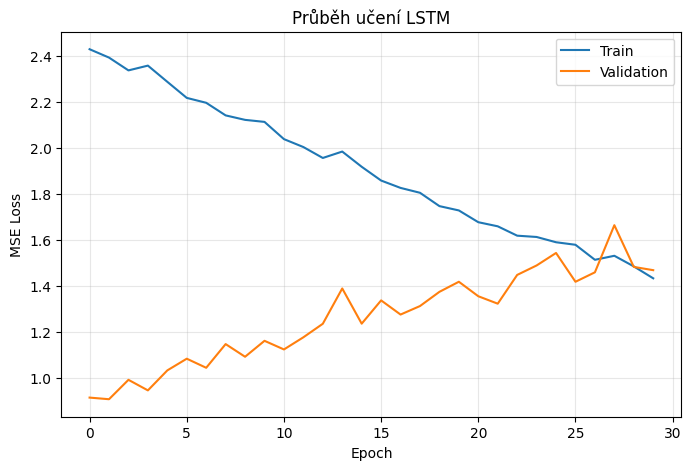

In [17]:
# graf učení

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train")

plt.plot(valid_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title("Průběh učení LSTM")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

## 10. Vyhodnocení modelu LSTM

In [28]:
lstm_model.eval()

predictions = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        pred = lstm_model(X_batch)

        predictions.extend(pred.numpy())

predictions = np.array(predictions)

In [29]:
# Spočítání metrik

lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, predictions))
lstm_mae = mean_absolute_error(y_test_seq, predictions)
lstm_r2 = r2_score(y_test_seq, predictions)

print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAE : {lstm_mae:.4f}")
print(f"R²  : {lstm_r2:.4f}")

RMSE: 6.9810
MAE : 5.5323
R²  : -0.2702


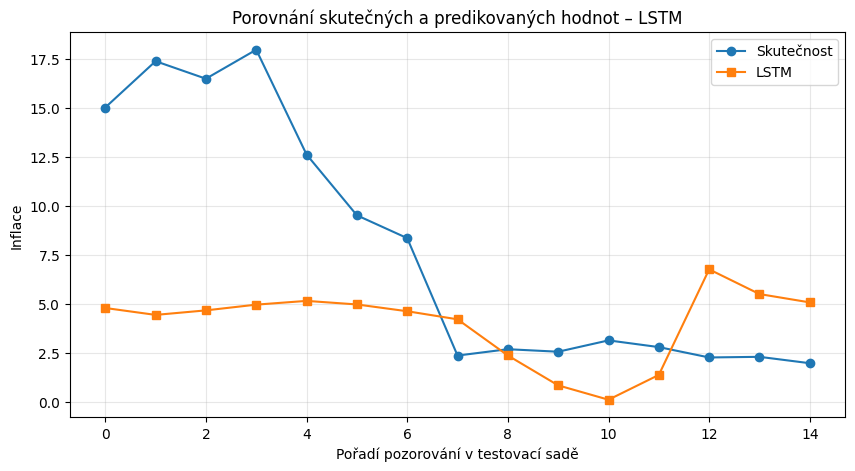

In [32]:
# graf skutečnost vs. predikce pro LSTM

plt.figure(figsize=(10,5))

plt.plot(y_test_seq, marker="o", label="Skutečnost")
plt.plot(predictions, marker="s", label="LSTM")

plt.title("Porovnání skutečných a predikovaných hodnot – LSTM")
plt.xlabel("Pořadí pozorování v testovací sadě")
plt.ylabel("Inflace")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## 11. Definice modelu GRU

In [33]:
class GRURegressor(nn.Module):

    def __init__(self,
                 input_size,
                 hidden_size=32,
                 num_layers=1):

        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.gru(x)

        out = out[:, -1, :]      # poslední časový krok

        out = self.fc(out)

        return out.squeeze()

In [34]:
gru_model = GRURegressor(
    input_size=4,
    hidden_size=32
)

print(gru_model)

GRURegressor(
  (gru): GRU(4, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [36]:
# Trénování GRU

criterion = nn.MSELoss()

gru_optimizer = optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

In [42]:
start_time = time.perf_counter()

gru_train_losses, gru_valid_losses, gru_best_valid_loss, gru_best_epoch = train_model(
    gru_model,
    train_loader,
    valid_loader,
    criterion,
    gru_optimizer,
    epochs=30
)

end_time = time.perf_counter()

gru_training_time = end_time - start_time

print(f"\nDoba trénování GRU: {gru_training_time:.2f} s")

Epoch   3 | Train: 2.3344 | Valid: 1.3624
Epoch   6 | Train: 2.1875 | Valid: 1.3731
Epoch   9 | Train: 2.0424 | Valid: 1.5544
Epoch  12 | Train: 1.9532 | Valid: 1.7323
Epoch  15 | Train: 1.9027 | Valid: 1.7686
Epoch  18 | Train: 1.8167 | Valid: 1.9133
Epoch  21 | Train: 1.7696 | Valid: 1.8963
Epoch  24 | Train: 1.7475 | Valid: 2.2832
Epoch  27 | Train: 1.6482 | Valid: 2.3628
Epoch  30 | Train: 1.5937 | Valid: 2.3526


ValueError: not enough values to unpack (expected 4, got 2)

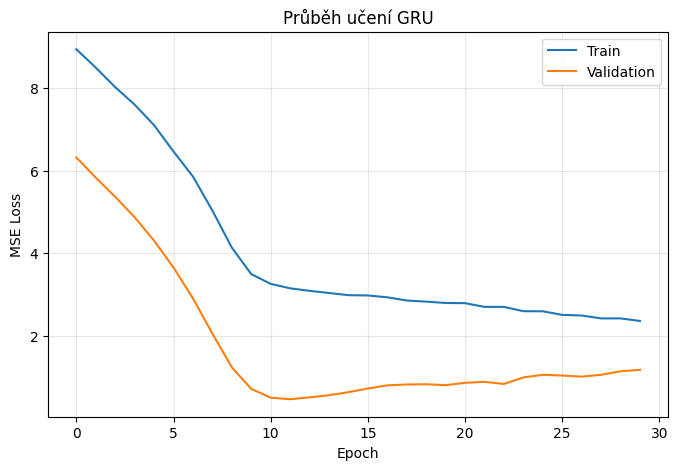

In [38]:
# Graf učení GRU

plt.figure(figsize=(8,5))

plt.plot(gru_train_losses, label="Train")
plt.plot(gru_valid_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Průběh učení GRU")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## 7. Trénink a vyhodnocení modelů
 - ?????? smazat

In [ ]:
results = []
predictions_test = {}

# Baseline z HW2 – naivní časová predikce
baseline_train_pred = train["baseline"]
baseline_valid_pred = valid["baseline"]
baseline_test_pred = test["baseline"]

train_mae, train_rmse, train_r2 = regression_metrics(y_train, baseline_train_pred)
valid_mae, valid_rmse, valid_r2 = regression_metrics(y_valid, baseline_valid_pred)
test_mae, test_rmse, test_r2 = regression_metrics(y_test, baseline_test_pred)

results.append({
    "model": "Baseline_HW2",
    "train_MAE": train_mae,
    "valid_MAE": valid_mae,
    "test_MAE": test_mae,
    "train_RMSE": train_rmse,
    "valid_RMSE": valid_rmse,
    "test_RMSE": test_rmse,
    "train_R2": train_r2,
    "valid_R2": valid_r2,
    "test_R2": test_r2,
    "overfit_gap_RMSE": test_rmse - train_rmse
})

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_valid_pred = model.predict(X_valid)
    y_test_pred = model.predict(X_test)

    predictions_test[name] = y_test_pred

    train_mae, train_rmse, train_r2 = regression_metrics(y_train, y_train_pred)
    valid_mae, valid_rmse, valid_r2 = regression_metrics(y_valid, y_valid_pred)
    test_mae, test_rmse, test_r2 = regression_metrics(y_test, y_test_pred)

    results.append({
        "model": name,
        "train_MAE": train_mae,
        "valid_MAE": valid_mae,
        "test_MAE": test_mae,
        "train_RMSE": train_rmse,
        "valid_RMSE": valid_rmse,
        "test_RMSE": test_rmse,
        "train_R2": train_r2,
        "valid_R2": valid_r2,
        "test_R2": test_r2,
        "overfit_gap_RMSE": test_rmse - train_rmse
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("test_RMSE").reset_index(drop=True)

results_df

,model,train_MAE,valid_MAE,test_MAE,train_RMSE,valid_RMSE,test_RMSE,train_R2,valid_R2,test_R2,overfit_gap_RMSE
0,Ridge,0.866864,1.785561,2.244964,1.118136,2.191834,2.568989,0.828573,-5.804872,0.801067,1.450853
1,ElasticNet,0.866532,1.801942,2.249231,1.117516,2.209089,2.574773,0.828763,-5.912430,0.800170,1.457256
2,Lasso,0.866061,1.808068,2.251391,1.117401,2.214883,2.577132,0.828799,-5.948738,0.799804,1.459731
3,LinearRegression,0.867390,1.828040,2.254608,1.117120,2.239225,2.584594,0.828885,-6.102312,0.798643,1.467474
4,Baseline_HW2,1.448224,0.576288,3.242240,1.953782,0.762672,4.579724,0.476591,0.176090,0.367791,2.625943
5,KNN,0.911192,1.152897,3.880527,1.244627,1.403499,5.669840,0.787594,-1.790157,0.031000,4.425214
6,GradientBoosting,0.133104,1.360131,4.634921,0.167495,1.585215,5.960059,0.996153,-2.559431,-0.070738,5.792564
7,RandomForest,0.348628,1.326391,4.501314,0.453960,1.551384,5.980613,0.971743,-2.409127,-0.078136,5.526653
8,DecisionTree,0.000000,1.307543,5.401599,0.000000,1.566385,6.808103,1.000000,-2.475375,-0.397123,6.808103
9,SVR,0.980587,1.165099,5.060639,1.514915,1.399771,7.200461,0.685322,-1.775352,-0.562798,5.685545


Úloha je formulována jako regresní problém, proto jsou pro hodnocení použity metriky RMSE, MAE a R².

# ?????smayat>><<<<



## 9. Přehled výsledků na testovací sadě

Následující tabulka je hlavním finálním porovnáním modelů. Řazení je podle `test_RMSE`, tedy podle chyby na testovací sadě.

In [ ]:
final_table = results_df[[
    "model", "test_MAE", "test_RMSE", "test_R2", "train_RMSE", "overfit_gap_RMSE"
]].copy()

final_table = final_table.sort_values("test_RMSE").reset_index(drop=True)
final_table

,model,test_MAE,test_RMSE,test_R2,train_RMSE,overfit_gap_RMSE
0,Ridge,2.244964,2.568989,0.801067,1.118136,1.450853
1,ElasticNet,2.249231,2.574773,0.800170,1.117516,1.457256
2,Lasso,2.251391,2.577132,0.799804,1.117401,1.459731
3,LinearRegression,2.254608,2.584594,0.798643,1.117120,1.467474
4,Baseline_HW2,3.242240,4.579724,0.367791,1.953782,2.625943
5,KNN,3.880527,5.669840,0.031000,1.244627,4.425214
6,GradientBoosting,4.634921,5.960059,-0.070738,0.167495,5.792564
7,RandomForest,4.501314,5.980613,-0.078136,0.453960,5.526653
8,DecisionTree,5.401599,6.808103,-0.397123,0.000000,6.808103
9,SVR,5.060639,7.200461,-0.562798,1.514915,5.685545


## 10. Grafické porovnání podle RMSE

In [ ]:
print(results_df.head())

              model  train_MAE  valid_MAE  test_MAE  train_RMSE  valid_RMSE  test_RMSE  train_R2  valid_R2   test_R2  \
0             Ridge   0.866864   1.785561  2.244964    1.118136    2.191834   2.568989  0.828573 -5.804872  0.801067   
1        ElasticNet   0.866532   1.801942  2.249231    1.117516    2.209089   2.574773  0.828763 -5.912430  0.800170   
2             Lasso   0.866061   1.808068  2.251391    1.117401    2.214883   2.577132  0.828799 -5.948738  0.799804   
3  LinearRegression   0.867390   1.828040  2.254608    1.117120    2.239225   2.584594  0.828885 -6.102312  0.798643   
4      Baseline_HW2   1.448224   0.576288  3.242240    1.953782    0.762672   4.579724  0.476591  0.176090  0.367791   

   overfit_gap_RMSE  
0          1.450853  
1          1.457256  
2          1.459731  
3          1.467474  
4          2.625943  


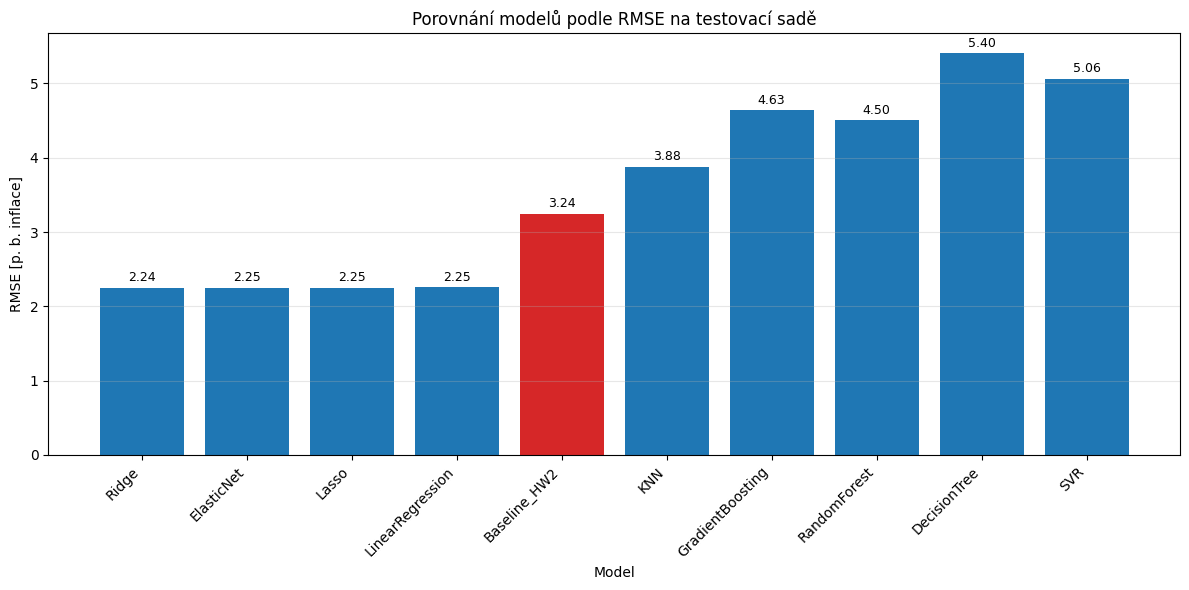

In [ ]:
plt.figure(figsize=(12, 6))

colors = [
    "tab:red" if model == "Baseline_HW2"
    else "tab:blue"
    for model in final_table["model"]
]
bars = plt.bar(
    final_table["model"],
    final_table["test_MAE"],
    color=colors
)


plt.title("Porovnání modelů podle RMSE na testovací sadě")
plt.ylabel("RMSE [p. b. inflace]")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

# hodnoty nad sloupci
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.show()

## 11. Grafické porovnání podle MAE

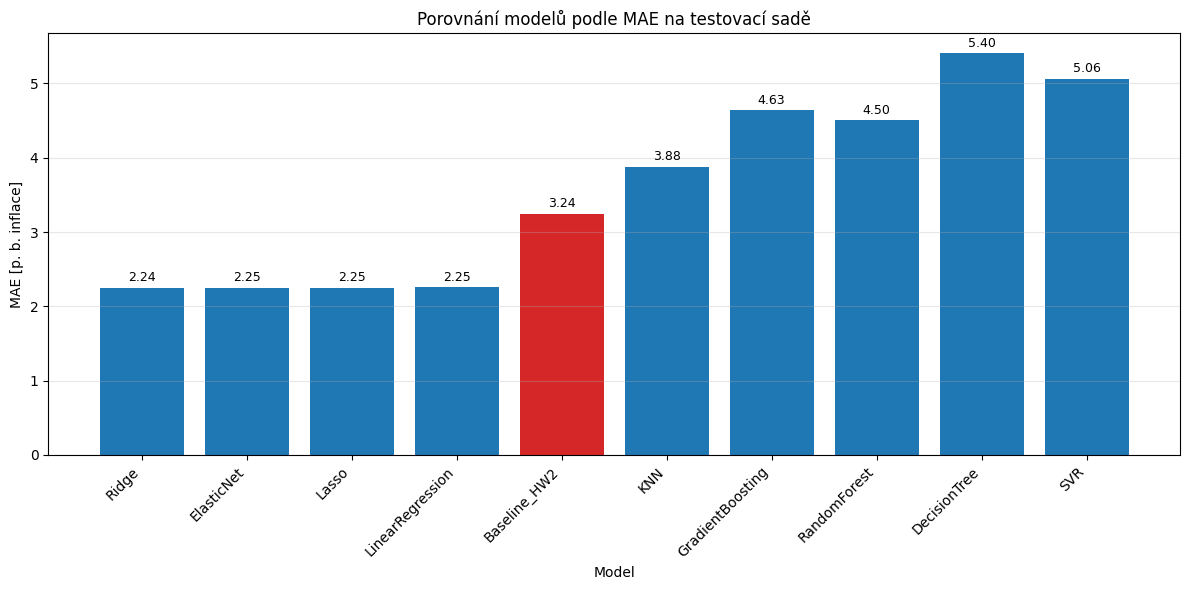

In [ ]:
plt.figure(figsize=(12, 6))

colors = [
    "tab:red" if model == "Baseline_HW2"
    else "tab:blue"
    for model in final_table["model"]
]
bars = plt.bar(
    final_table["model"],
    final_table["test_MAE"],
    color=colors
)

plt.title("Porovnání modelů podle MAE na testovací sadě")
plt.ylabel("MAE [p. b. inflace]")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

# hodnoty nad sloupci
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 12. Kontrola možného přeučení

Přeučení se může projevit tak, že model má velmi nízkou chybu na trénovacích datech, ale výrazně horší chybu na testovacích datech.

In [ ]:
overfit_table = results_df[[
    "model", "train_RMSE", "test_RMSE", "overfit_gap_RMSE"
]].sort_values("overfit_gap_RMSE", ascending=False)

overfit_table

,model,train_RMSE,test_RMSE,overfit_gap_RMSE
8,DecisionTree,0.000000,6.808103,6.808103
6,GradientBoosting,0.167495,5.960059,5.792564
9,SVR,1.514915,7.200461,5.685545
7,RandomForest,0.453960,5.980613,5.526653
5,KNN,1.244627,5.669840,4.425214
4,Baseline_HW2,1.953782,4.579724,2.625943
3,LinearRegression,1.117120,2.584594,1.467474
2,Lasso,1.117401,2.577132,1.459731
1,ElasticNet,1.117516,2.574773,1.457256
0,Ridge,1.118136,2.568989,1.450853


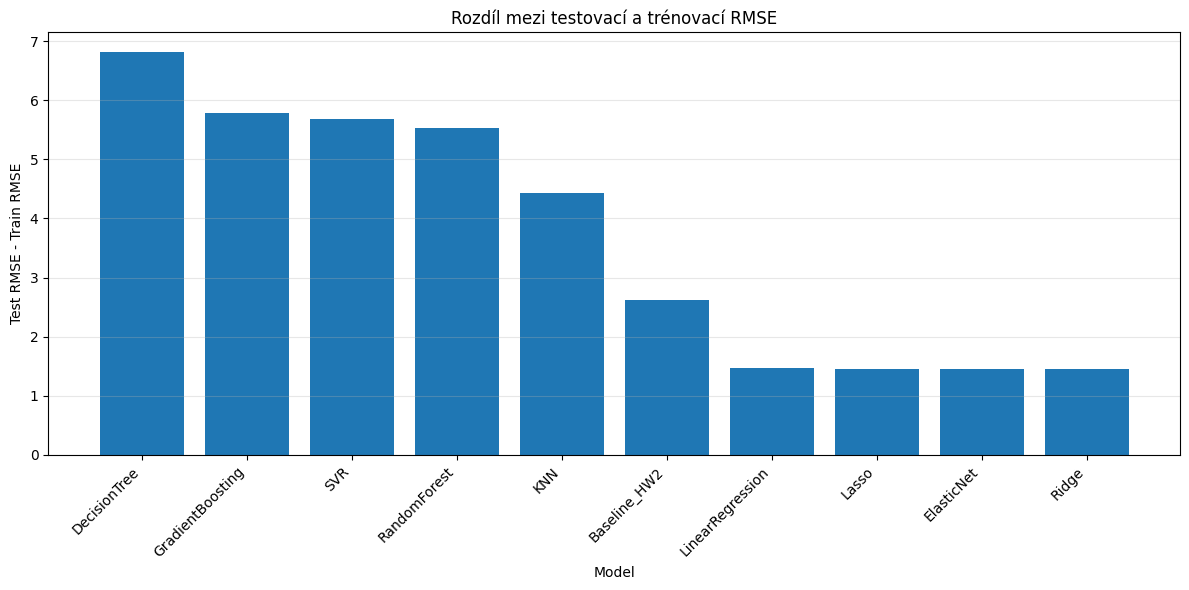

In [ ]:
plot_overfit = overfit_table.sort_values("overfit_gap_RMSE", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(plot_overfit["model"], plot_overfit["overfit_gap_RMSE"])
plt.title("Rozdíl mezi testovací a trénovací RMSE")
plt.ylabel("Test RMSE - Train RMSE")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Porovnání skutečných a predikovaných hodnot

V grafu porovnávám skutečnou inflaci v následujícím kvartálu s predikcí nejlepšího modelu podle testovací RMSE.

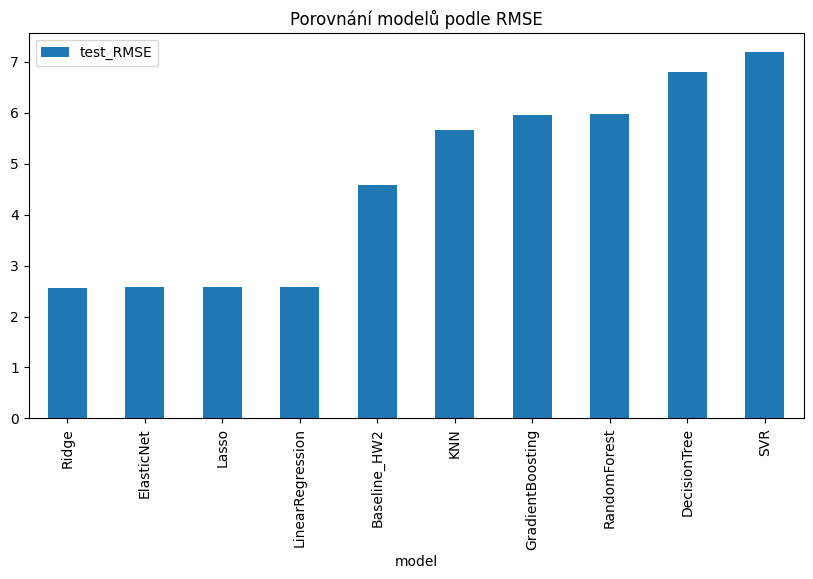

In [ ]:
results_df.sort_values("test_RMSE").plot(
    x="model",
    y="test_RMSE",
    kind="bar",
    figsize=(10,5),
    title="Porovnání modelů podle RMSE"
)
plt.show()

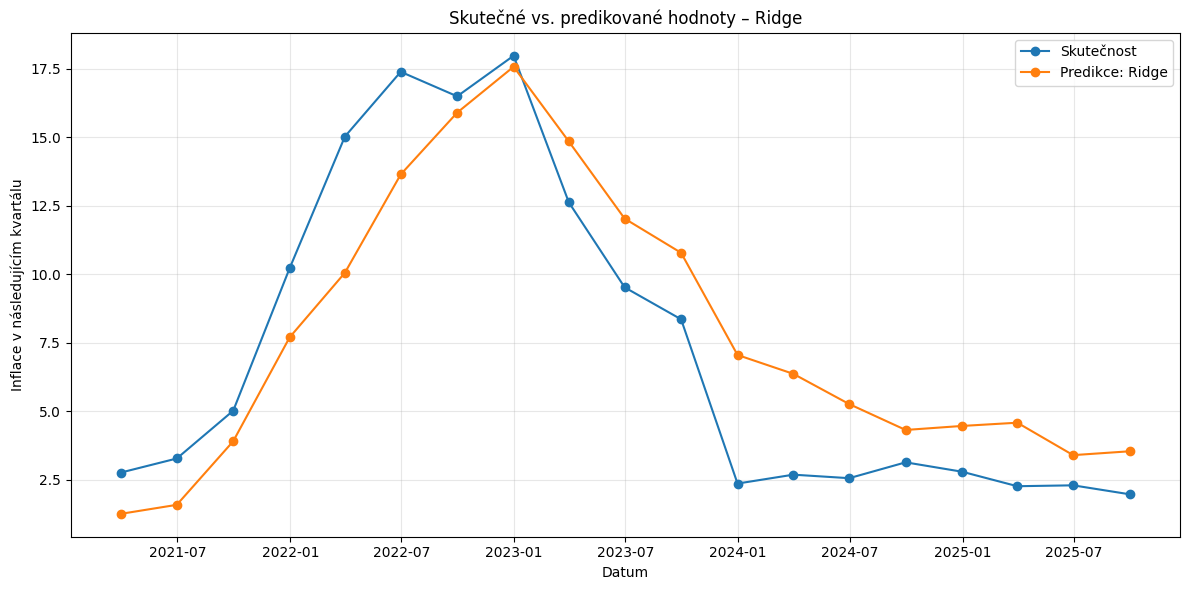

Nejlepší model podle testovací RMSE: Ridge


In [ ]:
best_model_name = results_df.sort_values("test_RMSE").iloc[0]["model"]

if best_model_name == "Baseline_HW2":
    best_model_pred = baseline_test_pred
else:
    best_model_pred = predictions_test[best_model_name]

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, marker="o", label="Skutečnost")
plt.plot(y_test.index, best_model_pred, marker="o", label=f"Predikce: {best_model_name}")
plt.title(f"Skutečné vs. predikované hodnoty – {best_model_name}")
plt.ylabel("Inflace v následujícím kvartálu")
plt.xlabel("Datum")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Nejlepší model podle testovací RMSE:", best_model_name)

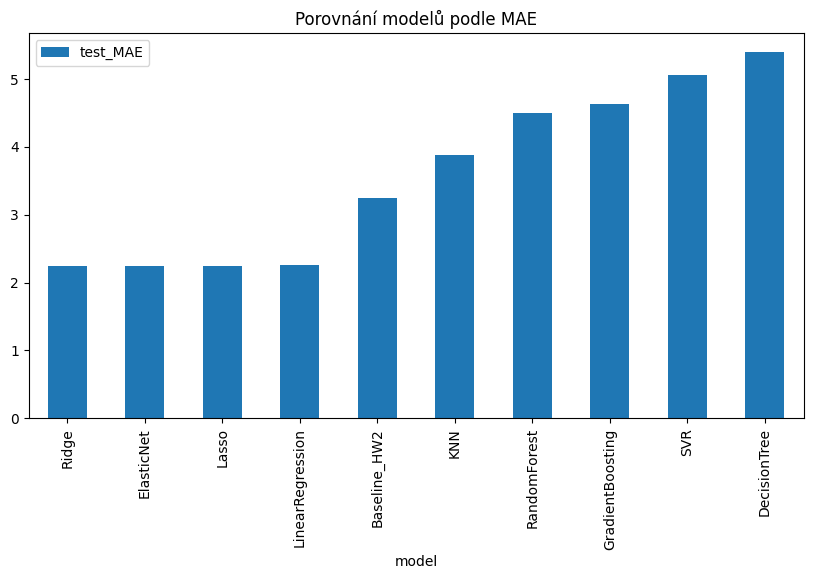

In [ ]:
results_df.sort_values("test_MAE").plot(
    x="model",
    y="test_MAE",
    kind="bar",
    figsize=(10,5),
    title="Porovnání modelů podle MAE"
)
plt.show()

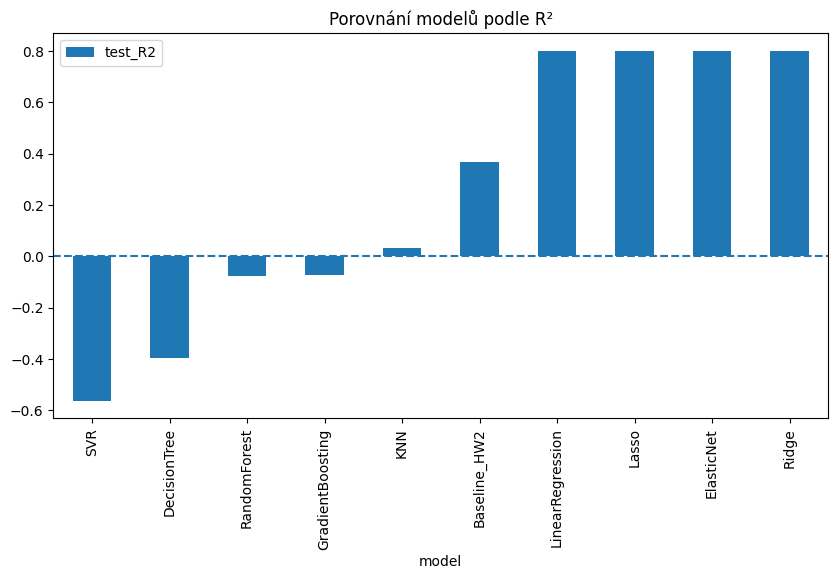

In [ ]:
results_df.sort_values("test_R2").plot(
    x="model",
    y="test_R2",
    kind="bar",
    figsize=(10,5),
    title="Porovnání modelů podle R²"
)
plt.axhline(y=0, linestyle="--")
plt.show()

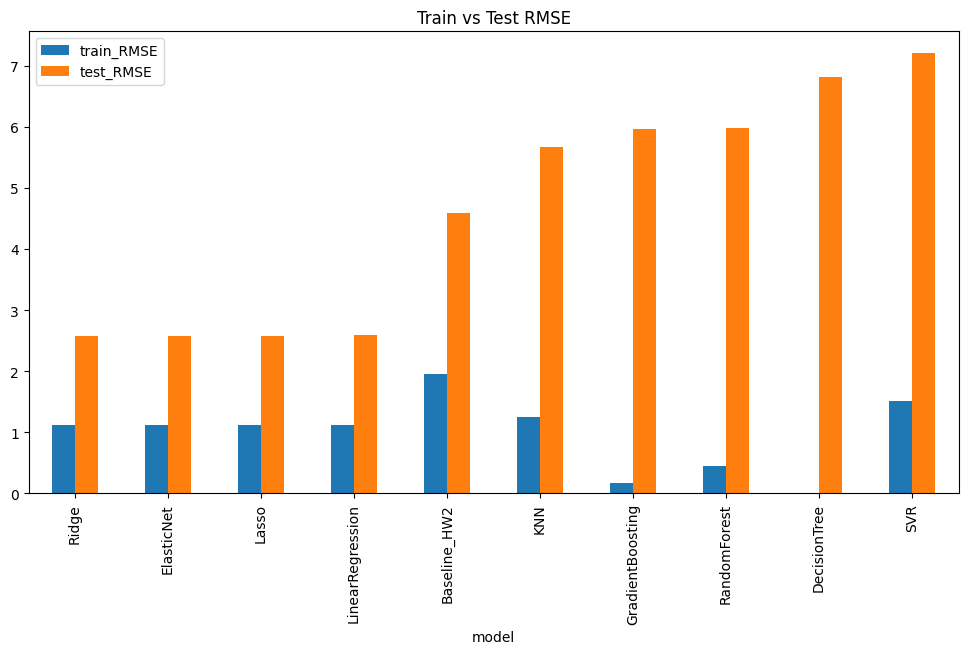

In [ ]:
results_df.plot(
    x="model",
    y=["train_RMSE","test_RMSE"],
    kind="bar",
    figsize=(12,6)
)

plt.title("Train vs Test RMSE")
plt.show()

## 14. Porovnání s baseline modelem z HW2


In [ ]:
best_row = results_df.sort_values("test_RMSE").iloc[0]
baseline_row = results_df[results_df["model"] == "Baseline_HW2"].iloc[0]

absolute_improvement = baseline_row["test_RMSE"] - best_row["test_RMSE"]
relative_improvement = absolute_improvement / baseline_row["test_RMSE"] * 100

print("Nejlepší model:", best_row["model"])
print("RMSE nejlepšího modelu:", round(best_row["test_RMSE"], 4))
print("RMSE baseline z HW2:", round(baseline_row["test_RMSE"], 4))
print("Absolutní zlepšení RMSE:", round(absolute_improvement, 4))
print("Relativní zlepšení RMSE v %:", round(relative_improvement, 2))

Nejlepší model: Ridge
RMSE nejlepšího modelu: 2.569
RMSE baseline z HW2: 4.5797
Absolutní zlepšení RMSE: 2.0107
Relativní zlepšení RMSE v %: 43.91


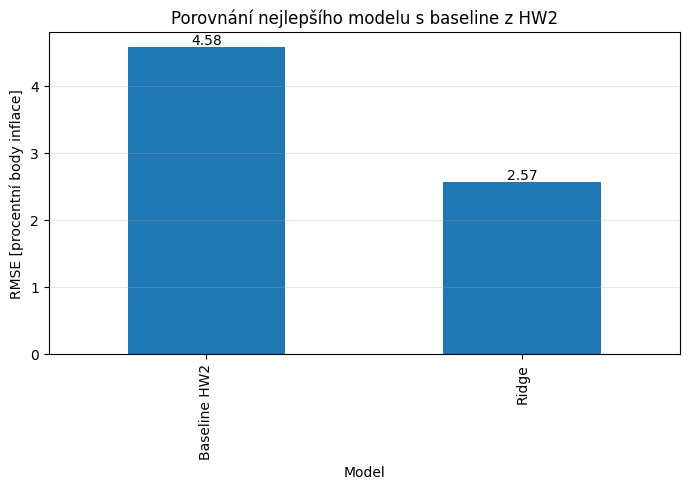

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Baseline HW2", best_row["model"]],
    "RMSE": [
        baseline_row["test_RMSE"],
        best_row["test_RMSE"]
    ]
})

ax = comparison.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    figsize=(7,5),
    legend=False,
    title="Porovnání nejlepšího modelu s baseline z HW2"
)

plt.ylabel("RMSE [procentní body inflace]")
plt.xlabel("Model")
plt.grid(axis="y", alpha=0.3)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

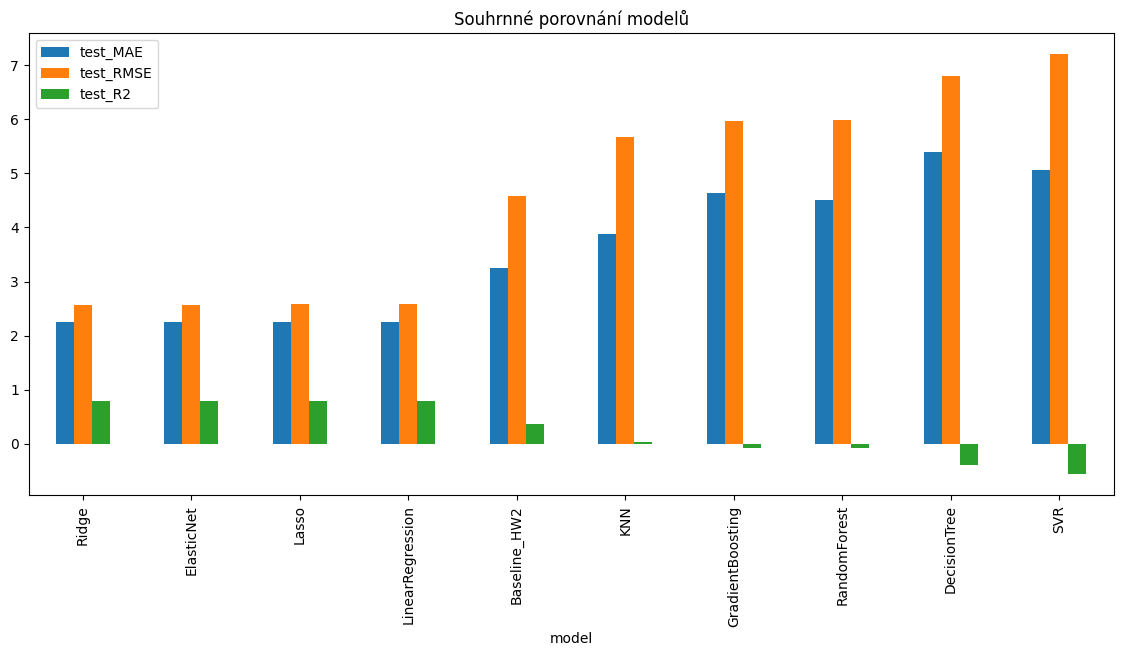

In [ ]:
metrics_plot = results_df.set_index("model")[
    ["test_MAE","test_RMSE","test_R2"]
]

metrics_plot.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Souhrnné porovnání modelů")
plt.show()

## 15. Diskuze výsledků
